In [177]:
import cvxpy as cp
import networkx as nx
import numpy as np

In [238]:
graph = nx.read_gml("arjun.gml")
resource_graph = nx.read_gml("aladdin_const_with_mem.gml")
lengths = dict(nx.all_pairs_shortest_path_length(graph))
topo_sort_graph = list(nx.topological_sort(graph))
indices = list(range(1, len(topo_sort_graph) + 1))
position_dict = dict(zip(topo_sort_graph, indices))
graph_nodes = graph.nodes(data=True)

hw_element_counts = {'MainMem': 1, 'Mult': 1, 'Eq': 1, 'Buf': 1, 'Add': 1, 'Regs': 2, 'stall': float('inf')}
hw_allocations = [('Add0', 1103), ('Regs0', 1100), ('Regs1', 2202), ('Regs2', 1000), ('Mult0', 1001), ('Eq0', 0), ('Buf0', 0), ('Buf1', 0), ('Mem0', 0), ('Regs3', 0)]

### Creating variables and Data dependencies

In [239]:
# creating variables
# only need two per node: start and end?
constraints = []
vars = []

# graph nodes
id = 0
for node in graph_nodes:
    curr_var = cp.Variable(2) # first one is start time and last one is end time
    vars.append(curr_var)
    # start time + latency = end time for each operating node
    node[1]['scheduling_id'] = id
    id += 1
    constraints.append(curr_var[0] >= 0)
    constraints.append(curr_var[1] >= 0)
    if 'cost' in node[1].keys():
        constraints.append(curr_var[0] + node[1]['cost'] == curr_var[1])

# print(graph_nodes)
# nx.set_node_attributes(graph, graph_nodes)
# data dependency constraints
for u, v in graph.edges():
    # if 'idx'
    source_id = int(graph_nodes[u]['scheduling_id'])
    dest_id = int(graph_nodes[v]['scheduling_id'])
    constraints.append(vars[source_id][1] - vars[dest_id][0] <= 0)

### Longest-path priority based topo sort

In [240]:
import heapq

def longest_path_first_topological_sort(graph):
    longest_path_length = {node: 0 for node in graph.nodes()}
    for node in reversed(list(nx.topological_sort(graph))):
        for successor in graph.successors(node):
            longest_path_length[node] = max(longest_path_length[node], 1 + longest_path_length[successor])

    priority_queue = []
    in_degree = {node: 0 for node in graph.nodes()}
    for u, v in graph.edges():
        in_degree[v] += 1
    
    for node in graph.nodes():
        if in_degree[node] == 0:
            heapq.heappush(priority_queue, (-longest_path_length[node], node))

    topological_order = []
    while priority_queue:
        _, node = heapq.heappop(priority_queue)
        topological_order.append(node)
        for successor in graph.successors(node):
            in_degree[successor] -= 1
            if in_degree[successor] == 0:
                heapq.heappush(priority_queue, (-longest_path_length[successor], successor))

    return topological_order

# topo_order_longest_path = longest_path_first_topological_sort(graph)

### NetworkX Topological Sort Dependencies 

In [241]:
# topological_order = list(nx.topological_sort(graph))
topological_order = longest_path_first_topological_sort(graph)
for i in range(len(topological_order)):
    curr_reg_count = {'Regs': 0, 'Add': 0, 'Mult': 0, 'Buf': 0, 'Eq': 0}
    start_node = topological_order[i]
    if graph.nodes[start_node]['function'] not in curr_reg_count:
        continue
    curr_reg_count[graph.nodes[start_node]['function']] += 1
    for j in range(i + 1, len(topological_order)):
        curr_node = topological_order[j]
        if graph.nodes[curr_node]['function'] not in curr_reg_count:
            continue
        curr_reg_count[graph.nodes[curr_node]['function']] += 1
        if curr_reg_count[graph.nodes[curr_node]['function']] > hw_element_counts[graph.nodes[curr_node]['function']]:
            # add a constraint
            constraints.append(vars[graph.nodes[start_node]['scheduling_id']][1] - vars[graph.nodes[curr_node]['scheduling_id']][0] <= -graph.nodes[start_node]['cost'])

In [242]:
obj = cp.Minimize(vars[graph_nodes['end']['scheduling_id']][0])
prob = cp.Problem(obj, constraints)
prob.solve(solver='SCIPY', verbose=True)

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) May 01 10:49:31 AM: Your problem has 20 variables, 56 constraints, and 0 parameters.
(CVXPY) May 01 10:49:31 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 01 10:49:31 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 01 10:49:31 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 01 10:49:31 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) May 01 10:49:31 AM: Compiling problem (target solver=SCIPY).
(C

12.94

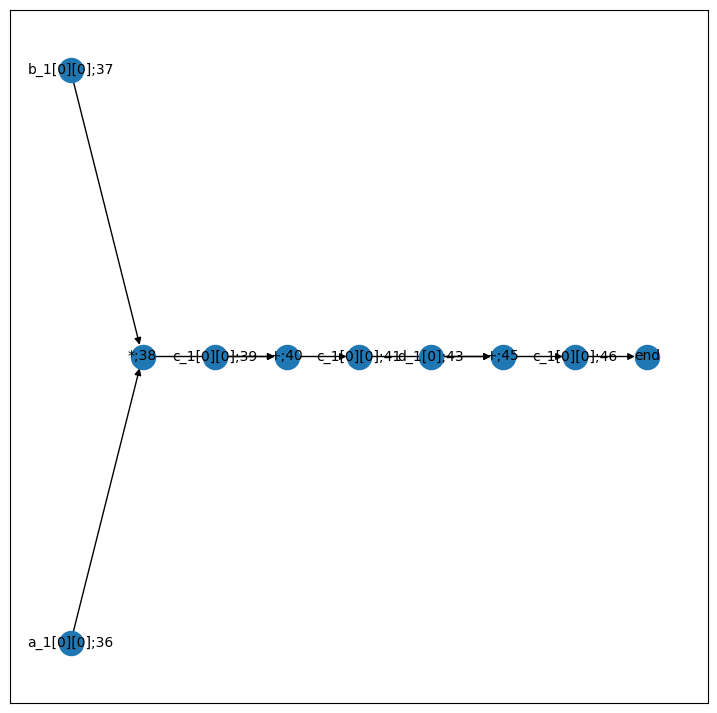

In [243]:
import matplotlib.pyplot as plt
for node in graph_nodes:
    start_time, end_time = vars[node[1]['scheduling_id']].value
    node[1]['start_time'] = start_time
    node[1]['end_time'] = end_time
plt.figure(figsize=(9,9))
nx.draw_networkx(graph, pos=nx.multipartite_layout(graph, subset_key="start_time"), font_size=10)

### Generational Resource Dependency (WRONG)

In [209]:
# generations = list(nx.topological_generations(nx.reverse(graph)))
# for elem in generations:
#     nodes = list(filter(lambda x: x[0] in elem, graph.nodes.data()))
#     funcs, counts = np.unique(
#         list(map(lambda x: x[1]["function"], nodes)), return_counts=True
#     )
#     for func, count in zip(funcs, counts):
#         if func == "start" or func == "end":
#                 continue            
#         if count > hw_element_counts[func]:
#             func_nodes = list(filter(lambda x: x[1]["function"] == func, nodes))
#             need_to_be_pushed = count - hw_element_counts[func]
#             sorted_by_outgoing_edges = sorted(func_nodes, key=lambda node: len(graph.out_edges()))
#             for i in range(need_to_be_pushed):
#                 for j in range(i + 1, need_to_be_pushed + 1):
#                     constraints.append(vars[int(func_nodes[i][1]['scheduling_id'])][0] - vars[int(func_nodes[j][1]['scheduling_id'])][0] <= -func_nodes[i][1]['cost'])
#                     # if there are 3 registers and 4 nodes using a register. then how do we encode the constraint?
#                     # every "layer "

### All Topological Sorts Dependencies

In [219]:
def limited_topological_sorts(graph, max_sorts=10):
    in_degree = {node: 0 for node in graph.nodes()}
    for u, v in graph.edges():
        in_degree[v] += 1

    partial_order = []
    sorts_found = 0
    
    def visit():
        nonlocal sorts_found
        if sorts_found >= max_sorts:
            return

        all_visited = True
        for node in graph.nodes():
            if in_degree[node] == 0 and node not in partial_order:
                all_visited = False
                partial_order.append(node)
                for successor in graph.successors(node):
                    in_degree[successor] -= 1

                yield from visit()

                partial_order.pop()
                for successor in graph.successors(node):
                    in_degree[successor] += 1
        
        if all_visited:
            sorts_found += 1
            yield list(partial_order)

    return list(visit())


all_sorted = limited_topological_sorts(graph, max_sorts = 10)
# print(all_sorted[0] == all_sorted[10])

final_vars = []
final_optim_val = float('inf')

all_optim_vals = []
print("Trying", len(all_sorted), "topological sorts")
for sort in all_sorted:
    curr_constraints = []

    ### Introducing Variables
    vars = []
    id = 0
    for node in graph_nodes:
        curr_var = cp.Variable(2) # first one is start time and last one is end time
        vars.append(curr_var)
        # start time + latency = end time for each operating node
        node[1]['scheduling_id'] = id
        id += 1
        curr_constraints.append(curr_var[0] >= 0)
        curr_constraints.append(curr_var[1] >= 0)
        if 'cost' in node[1].keys():
            curr_constraints.append(curr_var[0] + node[1]['cost'] == curr_var[1])
    
    ### Data Dependencies
    for u, v in graph.edges():
        # if 'idx'
        source_id = int(graph_nodes[u]['scheduling_id'])
        dest_id = int(graph_nodes[v]['scheduling_id'])
        curr_constraints.append(vars[source_id][1] - vars[dest_id][0] <= 0)
        
    ### Resource Dependencies
    for i in range(len(sort)):
        curr_reg_count = {'Regs': 0, 'Add': 0, 'Mult': 0, 'Buf': 0, 'Eq': 0}
        start_node = topological_order[i]
        if graph.nodes[start_node]['function'] not in curr_reg_count:
            continue
        curr_reg_count[graph.nodes[start_node]['function']] += 1
        for j in range(i + 1, len(topological_order)):
            curr_node = topological_order[j]
            if graph.nodes[curr_node]['function'] not in curr_reg_count:
                continue
            curr_reg_count[graph.nodes[curr_node]['function']] += 1
            if curr_reg_count[graph.nodes[curr_node]['function']] > hw_element_counts[graph.nodes[curr_node]['function']]:
                # add a constraint
                curr_constraints.append(vars[graph.nodes[start_node]['scheduling_id']][1] - vars[graph.nodes[curr_node]['scheduling_id']][0] <= -graph.nodes[start_node]['cost'])

    # constraints += curr_constraints
    obj = cp.Minimize(vars[graph_nodes['end']['scheduling_id']][0])
    prob = cp.Problem(obj, curr_constraints)
    prob.solve()
    all_optim_vals.append(prob.value)
    if prob.value < final_optim_val:
        final_optim_val = prob.value
        final_vars = vars
print("End Node Optimal Time: ", final_optim_val)
print("All Optimal Values: ", all_optim_vals)
print("All generated same optimal time:", all(i == all_optim_vals[0] for i in all_optim_vals))

Trying 10 topological sorts
End Node Optimal Time:  34.00000001584401
All Optimal Values:  [34.00000001584401, 34.00000001584401, 34.00000001584401, 34.00000001584401, 34.00000001584401, 34.00000001584401, 34.00000001584401, 34.00000001584401, 34.00000001584401, 34.00000001584401]
All generated same optimal time: True


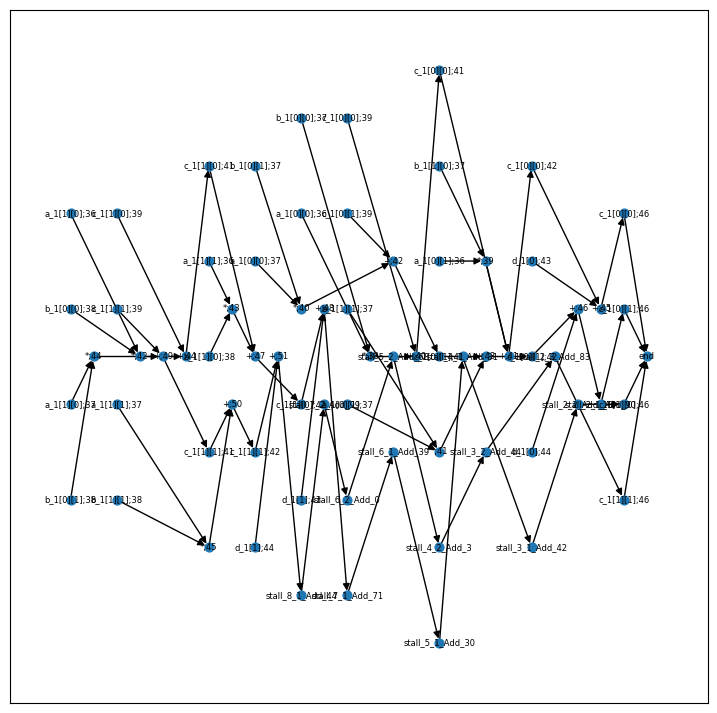

In [220]:
import matplotlib.pyplot as plt
for node in graph_nodes:
    start_time, end_time = vars[node[1]['scheduling_id']].value
    node[1]['start_time'] = np.round(start_time)
    node[1]['end_time'] = np.round(end_time)
plt.figure(figsize=(9,9))
nx.draw_networkx(graph, pos=nx.multipartite_layout(graph, subset_key="start_time"), node_size=40, font_size=6, label='function')

In [212]:
# get them back in order
for var in final_vars:
    print(int(var.value[0]), int(var.value[1]))

16 18
16 18
20 22
20 21
24 24
24 26
24 26
24 26
28 30
28 28
26 27
28 30
32 32
32 34
12 14
20 22
24 26
22 22
16 17
12 14
20 22
28 30
26 27
24 25
20 22
32 34
30 31
28 30
0 2
4 6
8 10
8 8
4 5
0 2
8 10
16 18
12 13
10 11
8 10
16 18
32 34
18 19
4 6
8 10
6 6
2 3
0 2
0 2
12 14
10 11
8 9
4 6
4 6
32 34
14 15
12 14
34 11
31 32
30 31
29 30
27 28
26 27
25 26
24 25
23 24
22 23
21 22
20 20
19 20
17 18
15 16
